In [580]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image, ImageStat
from tqdm import tqdm
from scipy.ndimage import label
from skimage import measure

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import f1_score
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [581]:
root_path = "/home/stefan/ioai-prep/kits/ojia-2026/webcam"
seed = 42

tqdm.pandas()

# Subtask 1

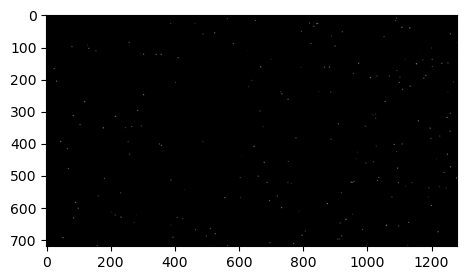

In [582]:
img = Image.open(f"{root_path}/xrays.png").convert("L")

plt.figure(figsize=(12,3))
plt.imshow(img, cmap='gray')

In [583]:
img = np.array(img)
subtask1 = (img > 0).sum()

subtask1

2393

# Subtask 2

## Data

In [779]:
def prep_df(df: pd.DataFrame, is_test=False) -> pd.DataFrame:
    def get_stats(file_name: str):
        path = f"{root_path}/{'train' if not is_test else 'test'}/{file_name}"
        img = Image.open(path).convert("L")
        arr = np.array(img)
        stat = ImageStat.Stat(img)

        mean = stat.mean[0]
        std = stat.stddev[0]
        total_pixels = np.sum(arr > 100)

        # count blobs:
        binary = arr > 100
        labeled_arr = measure.label(binary, connectivity=2)
        props = measure.regionprops(labeled_arr)

        n_blobs = len(props)
        small_blobs = sum(1 for p in props if p.area < 10)
        big_blobs = sum(1 for p in props if p.area >= 10)

        return pd.Series({
            "mean": mean,
            "std": std,
            "total_pixels": total_pixels,
            "n_blobs": n_blobs,
            "small_blobs": small_blobs,
            "big_blobs": big_blobs
        })

    return df["file_name"].progress_apply(get_stats)

In [780]:
df = pd.read_csv(f"{root_path}/train_data.csv")
df_train = prep_df(df)

df_train.head()

  0%|          | 0/300 [00:00<?, ?it/s]

100%|██████████| 300/300 [00:05<00:00, 52.30it/s]


,mean,std,total_pixels,n_blobs,small_blobs,big_blobs
0,0.265704,5.301461,927.0,170.0,147.0,23.0
1,0.195385,4.611831,687.0,112.0,90.0,22.0
2,0.120549,3.529208,403.0,71.0,58.0,13.0
3,0.080321,2.985646,290.0,47.0,37.0,10.0
4,0.120465,3.528540,404.0,71.0,58.0,13.0


In [781]:
df_test = pd.read_csv(f"{root_path}/test_data.csv")
test_feats = prep_df(df_test, is_test=True)

100%|██████████| 300/300 [00:06<00:00, 49.06it/s]


In [782]:
X_train, X_test, y_train, y_test = train_test_split(df_train, df["label"], test_size=0.2, stratify=df['label'], random_state=seed)

## Model

In [783]:
def evaluate(model):
    cv = cross_val_score(model, X_train, y_train, scoring='f1_macro', cv=3, n_jobs=-1)
    cv = cv.mean() - cv.std()

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    f1 = f1_score(y_test, preds, average='macro')
    return cv, f1

In [784]:
svc = LinearSVC(class_weight="balanced")

evaluate(svc)

(0.9542413756722966, 0.9665831244778613)

In [785]:
rf = RandomForestClassifier(n_estimators=400, max_depth=6, random_state=seed)

evaluate(rf)

(0.9287313218046195, 0.9497171590194847)

In [807]:
lr = LogisticRegression(max_iter=5000, class_weight='balanced', C=0.01, random_state=seed)

evaluate(lr)

(0.9518160157747522, 0.9326599326599326)

## Predictions

In [808]:
model = lr
model.fit(X_train, y_train)

subtask2 = model.predict(test_feats)

(array([107.,   0.,   0.,   0.,   0.,  92.,   0.,   0.,   0., 101.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

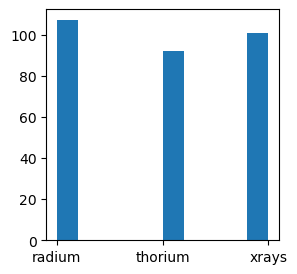

In [809]:
plt.figure(figsize=(3, 3))
plt.hist(subtask2)

# Submission

In [810]:
def build_subtask(sid, ans):
    return pd.DataFrame({
        "subtaskID": sid,
        "datapointID": [1] if sid == 1 else df_test["datapointID"],
        "answer": ans
    })

subtasks = [
    (1, subtask1),
    (2, subtask2)
]

submission = pd.concat([build_subtask(sid, ans) for sid, ans in subtasks])

In [811]:
submission.head()

,subtaskID,datapointID,answer
0,1,1,2393
0,2,1,radium
1,2,2,thorium
2,2,3,radium
3,2,4,xrays


In [812]:
submission.to_csv(f"{root_path}/submission.csv", index=False)